In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [18]:
edges = pd.read_pickle("edge_features.pkl")

print(edges.head())
print(edges.shape)

          u           v      length    highway  local_crime_norm  \
0    653688    21300195   88.746024  secondary          0.083614   
1    653688  1614655105  102.260072  secondary          0.062851   
2  21300195   122734101  119.001384  secondary          0.090909   
3  21300195   122842144  226.650664  secondary          0.053311   
4  21300195   122886545  313.026190  secondary          0.072952   

   local_severity_norm  distance_weighted_crime_norm  crime_kde_norm  \
0             0.669799                      0.007965        0.084060   
1             0.664286                      0.003505        0.071513   
2             0.671605                      0.007369        0.087414   
3             0.663158                      0.060181        0.073875   
4             0.667692                      0.047773        0.086923   

   avg_degree  edge_betweenness  ...  crime_hour_14  crime_hour_15  \
0         6.5          0.003058  ...              7              9   
1         5.0     

In [19]:
hours_df = pd.DataFrame({"HOUR": range(24)})

edges["edge_id"] = edges["u"].astype(str) + "_" + edges["v"].astype(str)

edge_hour_df = edges.merge(hours_df, how="cross")

In [20]:
edge_hour_df["hour_sin"] = np.sin(2*np.pi*edge_hour_df["HOUR"]/24)
edge_hour_df["hour_cos"] = np.cos(2*np.pi*edge_hour_df["HOUR"]/24)

edge_hour_df["is_weekend"] = edge_hour_df["HOUR"].isin([5,6]).astype(int)

In [21]:
# ── Step 1b: build time-aware risk label ─────────────────────────────────────

hour_cols = [f"crime_hour_{h}" for h in range(24)]

# Cross join edges × 24 hours (same as before)
hours_df = pd.DataFrame({"HOUR": range(24)})
edges["edge_id"] = edges["u"].astype(str) + "_" + edges["v"].astype(str)
edge_hour_df = edges.merge(hours_df, how="cross")

# Add time features (same as before)
edge_hour_df["hour_sin"] = np.sin(2 * np.pi * edge_hour_df["HOUR"] / 24)
edge_hour_df["hour_cos"] = np.cos(2 * np.pi * edge_hour_df["HOUR"] / 24)

# ── NEW: look up actual crime count for this edge at this specific hour ───────
# ── Faster vectorized version of the lookup (use this instead of apply) ──────

hour_matrix = edge_hour_df[hour_cols].values        # shape: (n_rows, 24)
hour_indices = edge_hour_df["HOUR"].values.astype(int)  # shape: (n_rows,)

# Pick the column matching each row's hour using advanced indexing
edge_hour_df["actual_crime_count"] = hour_matrix[
    np.arange(len(edge_hour_df)), hour_indices
]

# Weight crime count by average local severity → captures both volume and type
edge_hour_df["risk_label"] = (
    edge_hour_df["actual_crime_count"] * edge_hour_df["local_severity_norm"]
)

# Normalize to [0, 1]
max_val = edge_hour_df["risk_label"].max()
if max_val > 0:
    edge_hour_df["risk_label"] = edge_hour_df["risk_label"] / max_val
else:
    raise ValueError("All risk labels are 0 — check that hourly crime columns are populated")

# Sanity check — label should now vary across hours for the same edge
sample_edge = edge_hour_df[edge_hour_df["edge_id"] == edge_hour_df["edge_id"].iloc[0]]
print("Risk label variation across 24h for one edge:")
print(sample_edge[["HOUR", "actual_crime_count", "risk_label"]].to_string(index=False))
print(f"\nLabel range: {edge_hour_df['risk_label'].min():.4f} → {edge_hour_df['risk_label'].max():.4f}")
print(f"Label std:   {edge_hour_df['risk_label'].std():.4f}  (should be > 0.01)")

Risk label variation across 24h for one edge:
 HOUR  actual_crime_count  risk_label
    0                   2    0.011957
    1                   5    0.029892
    2                   2    0.011957
    3                   2    0.011957
    4                   4    0.023914
    5                   6    0.035870
    6                   2    0.011957
    7                   1    0.005978
    8                   5    0.029892
    9                   4    0.023914
   10                   7    0.041849
   11                   3    0.017935
   12                  15    0.089676
   13                  10    0.059784
   14                   7    0.041849
   15                   9    0.053806
   16                   9    0.053806
   17                   9    0.053806
   18                  10    0.059784
   19                   6    0.035870
   20                  10    0.059784
   21                   8    0.047827
   22                   4    0.023914
   23                   9    0.053806

Lab

Busiest edge: 73909677_21300257
Total crimes across all hours: 1782

 HOUR  actual_crime_count  risk_label
    0                  42    0.223160
    1                  41    0.217846
    2                  18    0.095640
    3                  12    0.063760
    4                  21    0.111580
    5                  18    0.095640
    6                  49    0.260353
    7                  79    0.419753
    8                  61    0.324113
    9                  75    0.398500
   10                  86    0.456946
   11                  93    0.494140
   12                  96    0.510080
   13                  90    0.478200
   14                 131    0.696046
   15                 127    0.674793
   16                  98    0.520706
   17                 116    0.616346
   18                 117    0.621659
   19                  95    0.504766
   20                  76    0.403813
   21                  72    0.382560
   22                  78    0.414440
   23              

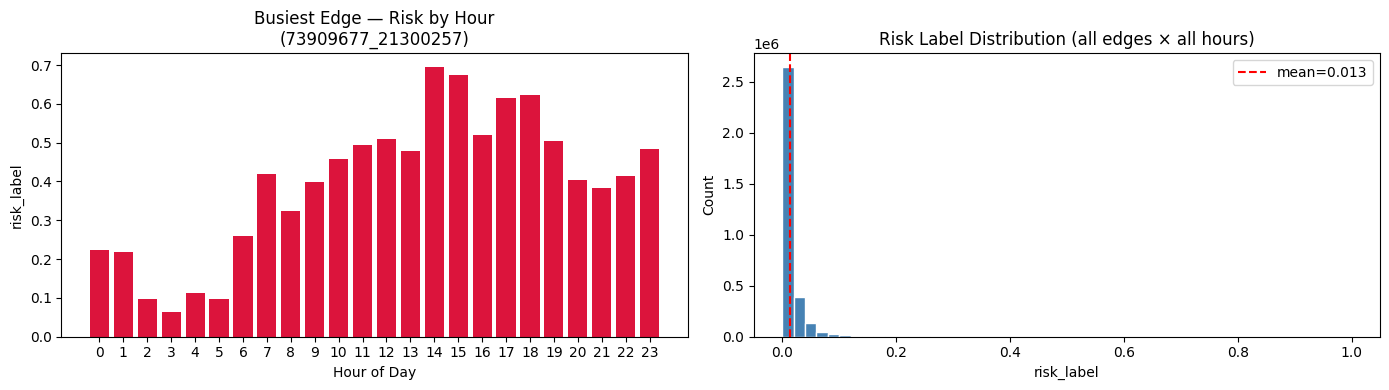


=== Per-edge label variance (should NOT be zero for busy edges) ===
Edges with zero variance across hours : 1886
Edges with non-zero variance          : 133728
Mean per-edge std                     : 0.00970
Max per-edge std                      : 0.31946

Quietest non-zero edge: 10187742874_122438524
 HOUR  actual_crime_count  risk_label
    0                   1    0.005355
    1                   0    0.000000
    2                   0    0.000000
    3                   0    0.000000
    4                   0    0.000000
    5                   0    0.000000
    6                   0    0.000000
    7                   0    0.000000
    8                   0    0.000000
    9                   0    0.000000
   10                   0    0.000000
   11                   0    0.000000
   12                   0    0.000000
   13                   0    0.000000
   14                   0    0.000000
   15                   0    0.000000
   16                   0    0.000000
   17       

In [22]:
# ── Proper single-edge hourly check ──────────────────────────────────────────

# Find the single busiest edge (most total crimes across all hours)
edge_total_crimes = edge_hour_df.groupby("edge_id")["actual_crime_count"].sum()
busiest_edge_id   = edge_total_crimes.idxmax()

single_edge = edge_hour_df[edge_hour_df["edge_id"] == busiest_edge_id].sort_values("HOUR")

print(f"Busiest edge: {busiest_edge_id}")
print(f"Total crimes across all hours: {edge_total_crimes[busiest_edge_id]}")
print()
print(single_edge[["HOUR", "actual_crime_count", "risk_label"]].to_string(index=False))

# ── Visual check ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: busiest edge risk across 24 hours
axes[0].bar(single_edge["HOUR"], single_edge["risk_label"], color="crimson")
axes[0].set_title(f"Busiest Edge — Risk by Hour\n({busiest_edge_id})")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("risk_label")
axes[0].set_xticks(range(24))

# Plot 2: overall risk label distribution across all edges and hours
axes[1].hist(edge_hour_df["risk_label"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Risk Label Distribution (all edges × all hours)")
axes[1].set_xlabel("risk_label")
axes[1].set_ylabel("Count")
axes[1].axvline(edge_hour_df["risk_label"].mean(), color="red",
                linestyle="--", label=f"mean={edge_hour_df['risk_label'].mean():.3f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("risk_label_check.png", dpi=120)
plt.show()

# ── Additional stats ─────────────────────────────────────────────────────────
print("\n=== Per-edge label variance (should NOT be zero for busy edges) ===")
per_edge_std = edge_hour_df.groupby("edge_id")["risk_label"].std()
print(f"Edges with zero variance across hours : {(per_edge_std == 0).sum()}")
print(f"Edges with non-zero variance          : {(per_edge_std > 0).sum()}")
print(f"Mean per-edge std                     : {per_edge_std.mean():.5f}")
print(f"Max per-edge std                      : {per_edge_std.max():.5f}")

# ── Check a quiet vs busy edge side by side ──────────────────────────────────
quietest_edge_id = edge_total_crimes[edge_total_crimes > 0].idxmin()
quiet_edge = edge_hour_df[edge_hour_df["edge_id"] == quietest_edge_id].sort_values("HOUR")

print(f"\nQuietest non-zero edge: {quietest_edge_id}")
print(quiet_edge[["HOUR", "actual_crime_count", "risk_label"]].to_string(index=False))

=== Final Label Stats ===
Std  : 0.0920  (want > 0.1)
Mean : 0.2194
Zero : 0  (want 0)
< 0.1: 8.5%
> 0.5: 0.4%


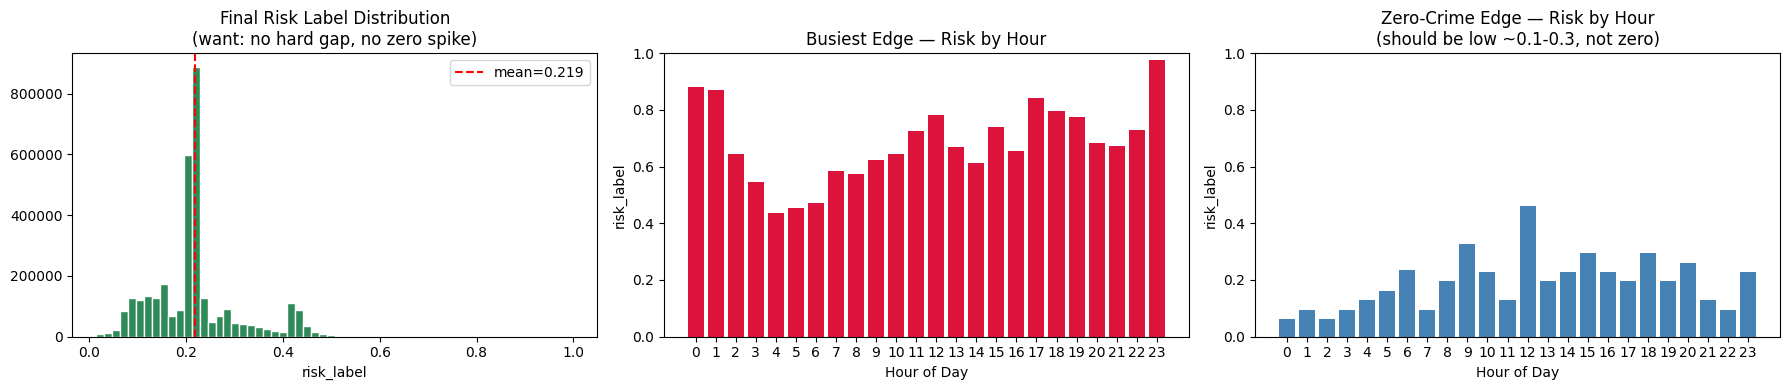

In [23]:
# ── Final fix: build risk score from multiple signals, not just crime count ───

# The problem: ~40% of edges have zero crimes → always predict 0 → useless for routing
# Solution: composite score using ALL available spatial signals so no edge is truly 0

edge_hour_df["risk_label_raw"] = edge_hour_df.get(
    "risk_label_raw",
    edge_hour_df["risk_label"].copy()
)

# ── Component 1: time-varying crime intensity (your good hourly signal) ───────
# Per-edge normalize to preserve hourly shape
edge_max   = edge_hour_df.groupby("edge_id")["risk_label_raw"].transform("max")
edge_min   = edge_hour_df.groupby("edge_id")["risk_label_raw"].transform("min")
edge_range = (edge_max - edge_min).clip(lower=1e-9)

time_signal = (edge_hour_df["risk_label_raw"] - edge_min) / edge_range
# Zero-crime edges: time_signal = 0/epsilon = 0 → override with 0.5 (neutral)
time_signal[edge_hour_df["risk_label_raw"] == 0] = 0.5

# ── Component 2: global crime density (spatial, time-invariant) ───────────────
spatial_signal = (
    0.5 * edge_hour_df["crime_kde_norm"] +
    0.3 * edge_hour_df["local_crime_norm"] +
    0.2 * edge_hour_df["distance_weighted_crime_norm"]
)
spatial_signal = spatial_signal / spatial_signal.max()

# ── Component 3: global crime intensity (how busy is this edge overall) ───────
intensity_signal = edge_hour_df["risk_label_raw"] / edge_hour_df["risk_label_raw"].max()

# ── Blend: weight each component ─────────────────────────────────────────────
# - 40% time pattern (captures WHEN)
# - 40% spatial density (captures WHERE, fills in zero-crime edges)
# - 20% raw intensity (preserves busiest edges at top)
edge_hour_df["risk_label"] = (
    0.40 * time_signal +
    0.40 * spatial_signal +
    0.20 * intensity_signal
)

# Final normalize
edge_hour_df["risk_label"] = (
    edge_hour_df["risk_label"] / edge_hour_df["risk_label"].max()
)

# ── Verify ────────────────────────────────────────────────────────────────────
print("=== Final Label Stats ===")
print(f"Std  : {edge_hour_df['risk_label'].std():.4f}  (want > 0.1)")
print(f"Mean : {edge_hour_df['risk_label'].mean():.4f}")
print(f"Zero : {(edge_hour_df['risk_label'] == 0).sum()}  (want 0)")
print(f"< 0.1: {(edge_hour_df['risk_label'] < 0.1).mean()*100:.1f}%")
print(f"> 0.5: {(edge_hour_df['risk_label'] > 0.5).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Distribution
axes[0].hist(edge_hour_df["risk_label"], bins=60,
             color="seagreen", edgecolor="white")
axes[0].set_title("Final Risk Label Distribution\n(want: no hard gap, no zero spike)")
axes[0].set_xlabel("risk_label")
axes[0].axvline(edge_hour_df["risk_label"].mean(), color="red",
                linestyle="--", label=f"mean={edge_hour_df['risk_label'].mean():.3f}")
axes[0].legend()

# Busiest edge
busiest_id = edge_hour_df.groupby("edge_id")["risk_label_raw"].sum().idxmax()
be = edge_hour_df[edge_hour_df["edge_id"] == busiest_id].sort_values("HOUR")
axes[1].bar(be["HOUR"], be["risk_label"], color="crimson")
axes[1].set_title("Busiest Edge — Risk by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("risk_label")
axes[1].set_xticks(range(24))
axes[1].set_ylim(0, 1)

# Quiet (zero-crime) edge
zero_edges = edge_hour_df[edge_hour_df["risk_label_raw"] == 0]["edge_id"].unique()
qe = edge_hour_df[edge_hour_df["edge_id"] == zero_edges[0]].sort_values("HOUR")
axes[2].bar(qe["HOUR"], qe["risk_label"], color="steelblue")
axes[2].set_title("Zero-Crime Edge — Risk by Hour\n(should be low ~0.1-0.3, not zero)")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("risk_label")
axes[2].set_xticks(range(24))
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("label_final_check.png", dpi=120)
plt.show()

In [24]:
# ── Final sanity check before training ───────────────────────────────────────

print("=== Ready to Train Check ===")
print(f"Total rows         : {len(edge_hour_df):,}")
print(f"Std                : {edge_hour_df['risk_label'].std():.4f}  ✅ want > 0.1")
print(f"Zero labels        : {(edge_hour_df['risk_label'] == 0).sum()}  ✅ want 0")
print(f"Negative labels    : {(edge_hour_df['risk_label'] < 0).sum()}  ✅ want 0")

# Confirm time signal is working — same edge should differ across hours
per_edge_std = edge_hour_df.groupby("edge_id")["risk_label"].std()
varying_edges = (per_edge_std > 0.01).sum()
total_edges   = per_edge_std.count()
print(f"Edges with hourly variation : {varying_edges:,} / {total_edges:,}  ✅ want > 50%")

# Confirm high-crime vs low-crime edges are separable
high = edge_hour_df[edge_hour_df["risk_label"] > 0.5]["risk_label"].mean()
low  = edge_hour_df[edge_hour_df["risk_label"] < 0.1]["risk_label"].mean()
print(f"High-risk mean     : {high:.4f}")
print(f"Low-risk mean      : {low:.4f}")
print(f"Separation ratio   : {high/low:.1f}x  ✅ want > 5x")

=== Ready to Train Check ===
Total rows         : 3,266,472
Std                : 0.0920  ✅ want > 0.1
Zero labels        : 0  ✅ want 0
Negative labels    : 0  ✅ want 0
Edges with hourly variation : 133,728 / 135,614  ✅ want > 50%
High-risk mean     : 0.5784
Low-risk mean      : 0.0789
Separation ratio   : 7.3x  ✅ want > 5x


In [11]:
feature_cols = [
    "length",
    "local_crime_norm",
    "distance_weighted_crime_norm",
    "crime_kde_norm",
    "avg_degree",
    "edge_betweenness",
    "hour_sin",
    "hour_cos",
    "is_weekend",
    "highway"
]

X = edge_hour_df[feature_cols]
y = edge_hour_df["risk_label"]

KeyError: "['is_weekend'] not in index"

In [13]:
categorical_features = ["highway"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [14]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.01267855611376373
RMSE: 0.01712837846982228
R2: 0.8378191836005389


In [17]:
import joblib
joblib.dump(pipeline, "road_risk_model.pkl")

['road_risk_model.pkl']

In [18]:
joblib.dump(feature_cols, "feature_columns.pkl")

['feature_columns.pkl']

In [17]:
# ── Fix: add is_weekend to edge_hour_df ──────────────────────────────────────
# is_weekend here means: what fraction of crimes near this edge were on weekends
# This is a property of the edge's crime profile, not the current time

# Check what columns exist first
print("Columns in edge_hour_df:", edge_hour_df.columns.tolist())

Columns in edge_hour_df: ['u', 'v', 'length', 'highway', 'local_crime_norm', 'local_severity_norm', 'distance_weighted_crime_norm', 'crime_kde_norm', 'avg_degree', 'edge_betweenness', 'x', 'y', 'crime_hour_0', 'crime_hour_1', 'crime_hour_2', 'crime_hour_3', 'crime_hour_4', 'crime_hour_5', 'crime_hour_6', 'crime_hour_7', 'crime_hour_8', 'crime_hour_9', 'crime_hour_10', 'crime_hour_11', 'crime_hour_12', 'crime_hour_13', 'crime_hour_14', 'crime_hour_15', 'crime_hour_16', 'crime_hour_17', 'crime_hour_18', 'crime_hour_19', 'crime_hour_20', 'crime_hour_21', 'crime_hour_22', 'crime_hour_23', 'edge_id', 'HOUR', 'hour_sin', 'hour_cos', 'actual_crime_count', 'risk_label', 'risk_label_raw', 'risk_label_local']


In [27]:
# ── Fix: add raw hourly crime counts as features ──────────────────────────────
# The model currently only knows WHAT TIME IT IS via hour_sin/cos
# It needs to also know HOW MANY CRIMES happened at this edge at this hour
# Those are already in edge_hour_df as crime_hour_0 ... crime_hour_23

# Instead of all 24 columns (too many, causes noise), create 4 time-bucket features
# that summarize crime patterns across time periods

edge_hour_df["crimes_night"]     = edge_hour_df[[f"crime_hour_{h}" for h in [0,1,2,3,4,5]]].sum(axis=1)
edge_hour_df["crimes_morning"]   = edge_hour_df[[f"crime_hour_{h}" for h in [6,7,8,9,10,11]]].sum(axis=1)
edge_hour_df["crimes_afternoon"] = edge_hour_df[[f"crime_hour_{h}" for h in [12,13,14,15,16,17]]].sum(axis=1)
edge_hour_df["crimes_evening"]   = edge_hour_df[[f"crime_hour_{h}" for h in [18,19,20,21,22,23]]].sum(axis=1)

# Normalize each bucket
for col in ["crimes_night","crimes_morning","crimes_afternoon","crimes_evening"]:
    max_val = edge_hour_df[col].max()
    if max_val > 0:
        edge_hour_df[col] = edge_hour_df[col] / max_val

# Also add the specific hour's crime count directly
# This is the most important feature — how many crimes at THIS edge at THIS hour
edge_hour_df["crimes_this_hour"] = edge_hour_df.apply(
    lambda row: row[f"crime_hour_{int(row['HOUR'])}"], axis=1
)
max_this_hour = edge_hour_df["crimes_this_hour"].max()
edge_hour_df["crimes_this_hour"] = edge_hour_df["crimes_this_hour"] / max_this_hour

print("New features added:")
print(edge_hour_df[["crimes_night","crimes_morning",
                     "crimes_afternoon","crimes_evening",
                     "crimes_this_hour"]].describe().round(4))

# ── Updated feature_cols ──────────────────────────────────────────────────────
feature_cols = [
    "length",
    "local_crime_norm",
    "distance_weighted_crime_norm",
    "crime_kde_norm",
    "avg_degree",
    "edge_betweenness",
    "hour_sin",
    "hour_cos",
    "weekend_crime_fraction",
    "crimes_night",        # ← new
    "crimes_morning",      # ← new
    "crimes_afternoon",    # ← new
    "crimes_evening",      # ← new
    "crimes_this_hour",    # ← new (most important)
    "highway"
]

X = edge_hour_df[feature_cols]
y = edge_hour_df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,        # increase back to 6 — more features need more depth
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)
pred_clipped = np.clip(pred, 0, 1)

print("\n=== Model Performance ===")
print(f"MAE  : {mean_absolute_error(y_test, pred_clipped):.5f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, pred_clipped)):.5f}")
print(f"R²   : {r2_score(y_test, pred_clipped):.4f}  (want > 0.6)")
print(f"\nPrediction range : {pred_clipped.min():.4f} → {pred_clipped.max():.4f}")
print(f"Prediction std   : {pred_clipped.std():.4f}  (want > 0.1)")

joblib.dump(pipeline, "road_risk_model.pkl")
joblib.dump(feature_cols, "feature_columns.pkl")
print("\n✅ Saved")

New features added:
       crimes_night  crimes_morning  crimes_afternoon  crimes_evening  \
count  3.266472e+06    3.266472e+06      3.266472e+06    3.266472e+06   
mean   2.260000e-02    1.220000e-02      2.010000e-02    2.670000e-02   
std    3.380000e-02    2.560000e-02      3.690000e-02    4.250000e-02   
min    0.000000e+00    0.000000e+00      0.000000e+00    0.000000e+00   
25%    2.900000e-03    2.200000e-03      3.600000e-03    4.800000e-03   
50%    1.150000e-02    5.500000e-03      9.500000e-03    1.440000e-02   
75%    2.880000e-02    1.430000e-02      2.380000e-02    3.360000e-02   
max    1.000000e+00    1.000000e+00      1.000000e+00    1.000000e+00   

       crimes_this_hour  
count      3.266472e+06  
mean       8.600000e-03  
std        1.790000e-02  
min        0.000000e+00  
25%        0.000000e+00  
50%        3.900000e-03  
75%        1.180000e-02  
max        1.000000e+00  

=== Model Performance ===
MAE  : 0.01818
RMSE : 0.03206
R²   : 0.8790  (want > 0.6)

Pr

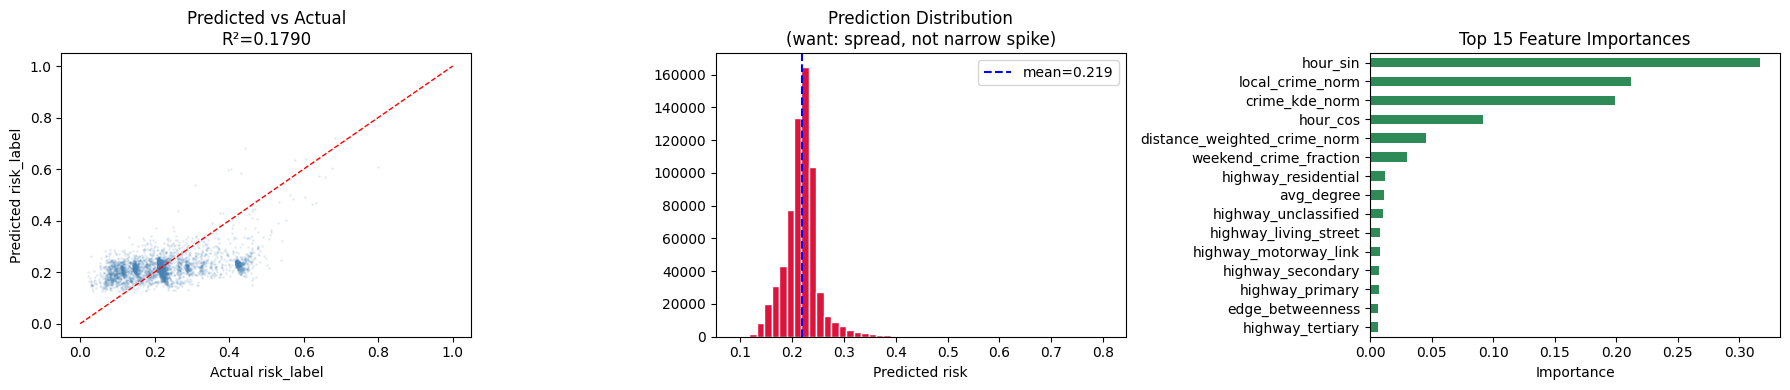

Top 10 features:
hour_sin                        0.317334
local_crime_norm                0.211999
crime_kde_norm                  0.199378
hour_cos                        0.092166
distance_weighted_crime_norm    0.045378
weekend_crime_fraction          0.029904
highway_residential             0.011788
avg_degree                      0.011196
highway_unclassified            0.010569
highway_living_street           0.008430


In [26]:
# ── Diagnose what the model is actually learning ──────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: predicted vs actual
axes[0].scatter(y_test[:5000], pred_clipped[:5000], alpha=0.1, s=1, color="steelblue")
axes[0].plot([0,1], [0,1], 'r--', linewidth=1)
axes[0].set_xlabel("Actual risk_label")
axes[0].set_ylabel("Predicted risk_label")
axes[0].set_title(f"Predicted vs Actual\nR²={r2_score(y_test, pred_clipped):.4f}")

# Plot 2: prediction distribution
axes[1].hist(pred_clipped, bins=50, color="crimson", edgecolor="white")
axes[1].set_title("Prediction Distribution\n(want: spread, not narrow spike)")
axes[1].set_xlabel("Predicted risk")
axes[1].axvline(pred_clipped.mean(), color="blue", linestyle="--",
                label=f"mean={pred_clipped.mean():.3f}")
axes[1].legend()

# Plot 3: feature importances
import pandas as pd
xgb_model = pipeline.named_steps["model"]
ohe_cols   = list(pipeline.named_steps["preprocessor"]
                  .named_transformers_["cat"]
                  .get_feature_names_out(["highway"]))
all_feature_names = ohe_cols + [c for c in feature_cols if c != "highway"]

importances = pd.Series(
    xgb_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=True).tail(15)

importances.plot(kind="barh", ax=axes[2], color="seagreen")
axes[2].set_title("Top 15 Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("model_diagnostics.png", dpi=120)
plt.show()

# Print top features
print("Top 10 features:")
print(importances.tail(10).sort_values(ascending=False).to_string())